# Demo 04 (PDF) — PDF Preprocessing

A companion to `markdown_preprocessing` (in `code/snippets/`) /
[`demo04_preprocessing_tools`](./demo04_preprocessing_tools.ipynb) — built for a forthcoming
chapter on PDF-based document ingestion. Those two notebooks work from a Markdown string that
*simulates* what an extractor returns. This one starts from **real PDF bytes**
(`demo04_pdf_preprocessing_handbook.pdf`, committed alongside this notebook — a 3-page handbook
built to exhibit the problems below) and hits failure modes a Markdown string cannot reproduce:

- a **two-column page** that a naive extractor reads as row-interleaved nonsense,
- a word **hyphenated across a line break**, the way real PDF text layout breaks it,
- a **real ruled table** (drawn with grid lines, not typed as `| a | b |`),
- a **figure with a caption** and no underlying text,
- **page furniture** (running header + footer + page number) repeating on every page.

Requires `pymupdf`, `pymupdf4llm`, `langchain-text-splitters`, `ftfy`, `sentence-transformers`
(all pip, CPU).

In [ ]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")   # this Mac's torch segfaults on MPS
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_VERBOSITY", "error")

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import fitz            # PyMuPDF
import pymupdf4llm
import ftfy
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

PDF_PATH = "demo04_pdf_preprocessing_handbook.pdf"
HEADER = "Bright Valley College — Student Handbook"

EMBED_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
_embedder = None
def embedder():
    global _embedder
    if _embedder is None:
        from sentence_transformers import SentenceTransformer
        _embedder = SentenceTransformer(EMBED_MODEL, device="cpu")
    return _embedder
def encode(texts):
    return embedder().encode(list(texts), normalize_embeddings=True)

print("ready")

## 1 — The document

A 3-page PDF: page 1 has plain single-column headings + a hyphenated line break, page 2 has a
**two-column layout** plus a ruled table, page 3 has a figure + caption. Rendering page 2 shows the
layout that will trip up a naive extractor.

3 pages


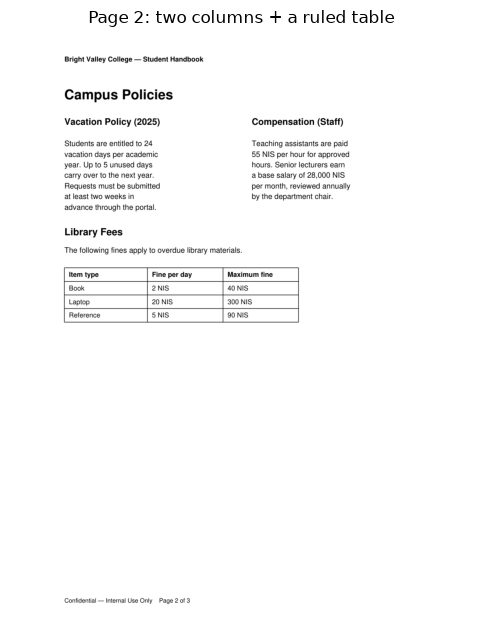

In [2]:
doc = fitz.open(PDF_PATH)
print(f"{len(doc)} pages")

page2 = doc[1]
pix = page2.get_pixmap(matrix=fitz.Matrix(1.6, 1.6))
img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
plt.figure(figsize=(5, 6.5))
plt.imshow(img)
plt.axis("off")
plt.title("Page 2: two columns + a ruled table")
plt.tight_layout()
plt.show()

## 2 — Naive extraction: hand-rolled from word boxes  (§6.2)

A common mistake when reconstructing text from bounding boxes (the same failure mode you'd hit
doing your own OCR post-processing, as in `demo13`): grab every word's box and sort **purely by
position** — top-to-bottom, then left-to-right. That ignores columns entirely.

In [3]:
def naive_extract(path):
    """Word-level (y, x) geometric sort -- ignores column structure entirely."""
    d = fitz.open(path)
    pages_text = []
    for page in d:
        words = page.get_text("words")  # (x0,y0,x1,y1, word, block_no, line_no, word_no)
        words_sorted = sorted(words, key=lambda w: (round(w[1]), w[0]))
        pages_text.append(" ".join(w[4] for w in words_sorted))
    return "\n".join(pages_text)

naive_text = naive_extract(PDF_PATH)
# the two-column paragraph, scrambled: notice "to 24" (left column) jumps straight to
# "Teaching assistants" (right column) before returning to "vacation days" (left column again).
start = naive_text.find("Vacation Policy")
print(naive_text[start:start + 220])

Vacation Policy (2025) Compensation (Staff) Students are entitled to 24 Teaching assistants are paid vacation days per academic 55 NIS per hour for approved year. Up to 5 unused days hours. Senior lecturers earn carry ov


## 3 — Structure-aware extraction: `pymupdf4llm`  (§6.2, §6.4)

`pymupdf4llm.to_markdown()` detects columns, recovers headings as real Markdown, converts the ruled
table to a Markdown grid, and **joins the hyphenated line break automatically** — none of which a
plain word-position sort can do.

In [4]:
library_md = pymupdf4llm.to_markdown(PDF_PATH)
print(library_md)

**Bright Valley College — Student Handbook** 

# **Course Policy** 

## **Assignments** 

Assignments are released weekly on the course portal. Each assignment is due by 23:59 on the stated deadline. 

### **Late submission** 

Assignments submitted after the deadline are accepted for up to five days. Each late assignment receives a penalty of 10 points per day, deducted from the final grade, with no exceptions except for documented medical emergencies. 

### **Grading** 

The passing grade for every course is 60 out of 100. A final grade below 60 requires the student to retake the course. 

Confidential — Internal Use Only    Page 1 of 3 

**Bright Valley College — Student Handbook** 

# **Campus Policies** 

### **Vacation Policy (2025)** 

### **Compensation (Staff)** 

Students are entitled to 24 vacation days per academic year. Up to 5 unused days carry over to the next year. Requests must be submitted at least two weeks in advance through the portal. 

Teaching assistants are pai

In [5]:
# the exact fix that mattered: the hyphenated break is gone.
naive_has_hyphen = "emer-" in naive_text
library_has_hyphen = "emer-" in library_md
print(f'naive extraction still has "emer-" line break: {naive_has_hyphen}')
print(f'pymupdf4llm already joined it:                  {"medical emergencies" in library_md} '
      f'(no hyphen left: {not library_has_hyphen})')

naive extraction still has "emer-" line break: True
pymupdf4llm already joined it:                  True (no hyphen left: True)


## 4 — Chunk with the same recipe as §6.4

This is the exact structure-aware pipeline from the chapter — `MarkdownHeaderTextSplitter` then
`RecursiveCharacterTextSplitter` — now running on a **real PDF's** Markdown instead of a simulated
string. Each chunk again carries its heading path in `.metadata`, for free.

In [6]:
header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "h1"), ("##", "h2"), ("###", "h3")],
    strip_headers=False,
)
sections = header_splitter.split_text(library_md)

small_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=0)
chunks = small_splitter.split_documents(sections)

def crumb(meta):
    return " > ".join(meta[k] for k in ("h1", "h2", "h3") if k in meta)

for d in chunks:
    print(f"[{crumb(d.metadata)}]  {d.page_content[:60].replace(chr(10), ' ')!r}")

[]  '**Bright Valley College — Student Handbook**'
[**Course Policy** > **Assignments**]  '# **Course Policy**   ## **Assignments**   Assignments are r'
[**Course Policy** > **Assignments** > **Late submission**]  '### **Late submission**   Assignments submitted after the de'
[**Course Policy** > **Assignments** > **Grading**]  '### **Grading**   The passing grade for every course is 60 o'
[**Campus Policies** > **Vacation Policy (2025)**]  '# **Campus Policies**   ### **Vacation Policy (2025)**'
[**Campus Policies** > **Compensation (Staff)**]  '### **Compensation (Staff)**   Students are entitled to 24 v'
[**Campus Policies** > **Library Fees**]  '## **Library Fees**   The following fines apply to overdue l'
[**Campus Map**]  '# **Campus Map**   _Figure 1. The main library reading room '


## 5 — Real per-page metadata, and cleaning the furniture  (§6.3, §6.5)

`pymupdf4llm.to_markdown(path, page_chunks=True)` returns one dict **per PDF page**, each carrying
real metadata (`page_number`, source file). Combined with the heading-path metadata from the
splitter, every chunk now has both **where in the document hierarchy** and **which physical page**
it came from — genuinely useful for citations ("page 2, Vacation Policy").

Page furniture is still not extraction's job to remove: the running header and the
`Confidential … Page N of 3` footer are still sitting in the Markdown. That part stays custom,
exactly as in `demo04_preprocessing_tools` — no generic tool knows *this* line is boilerplate.

In [7]:
def strip_furniture(text):
    kept = []
    for line in text.splitlines():
        s = line.strip()
        if not s or s.strip("* ") == HEADER or s.startswith("Confidential — Internal Use Only"):
            continue
        kept.append(ftfy.fix_text(line))
    return "\n".join(kept)

pages = pymupdf4llm.to_markdown(PDF_PATH, page_chunks=True)

records = []
for page in pages:
    cleaned = strip_furniture(page["text"])
    if not cleaned.strip():
        continue
    for d in small_splitter.split_documents(header_splitter.split_text(cleaned)):
        section = crumb(d.metadata)
        records.append({
            "text": d.page_content,
            "embed_text": f"Document section: {section}\n{d.page_content}" if section else d.page_content,
            "page": page["metadata"]["page_number"],
            "section": section,
        })

for r in records:
    print(f"[p{r['page']}] [{r['section']}]")

[p1] [**Course Policy** > **Assignments**]
[p1] [**Course Policy** > **Assignments** > **Late submission**]
[p1] [**Course Policy** > **Assignments** > **Grading**]
[p2] [**Campus Policies** > **Vacation Policy (2025)**]
[p2] [**Campus Policies** > **Compensation (Staff)**]
[p2] [**Campus Policies** > **Library Fees**]
[p3] [**Campus Map**]


## 6 — Evaluate through retrieval  (§6.7)

Known-answer recall@k, exactly as in the sibling notebooks — but the baseline here is the **naive
word-sort extraction + fixed-size chunking**, so the gap reflects two *genuine PDF-specific* defects
at once: column scrambling and un-joined hyphenation, not just chunk boundaries.

In [8]:
def fixed_size_chunks(text, size):
    return [text[i:i+size].strip() for i in range(0, len(text), size) if text[i:i+size].strip()]

gold = [
    ("What is the penalty for late submission?",        "10 points per day"),
    ("What covers exceptions to the late penalty?",      "medical emergencies"),
    ("How many vacation days do students get in 2025?",  "24 vacation days"),
    ("What is the daily library fine for a book?",       "2 NIS"),
    ("What is the passing grade?",                       "60 out of 100"),
]

def recall_at_k(chunk_texts, k):
    V = encode(chunk_texts); hits = 0
    for q, a in gold:
        order = np.argsort(-(V @ encode([q])[0]))[:k]
        hits += any(a in chunk_texts[i] for i in order)
    return hits / len(gold)

NAIVE_SIZE = 80
naive_chunks = fixed_size_chunks(naive_text, NAIVE_SIZE)
structured = [r["embed_text"] for r in records]

for k in (1, 2):
    print(f"recall@{k}:  naive(word-sort, size={NAIVE_SIZE}) = {recall_at_k(naive_chunks, k):.0%}   "
          f"pymupdf4llm+langchain = {recall_at_k(structured, k):.0%}")

# show WHY: the two real defects, visible in the naive chunks themselves
print("\nthe column-scrambled fragment (breaks the vacation-days answer):")
print("  ", next(c for c in naive_chunks if "Teaching assistants" in c and "24" in c))
print("the un-joined hyphenation (breaks the exceptions answer):")
print("  ", next(c for c in naive_chunks if "emer" in c.lower()))

recall@1:  naive(word-sort, size=80) = 0%   pymupdf4llm+langchain = 100%
recall@2:  naive(word-sort, size=80) = 20%   pymupdf4llm+langchain = 100%

the column-scrambled fragment (breaks the vacation-days answer):
   to 24 Teaching assistants are paid vacation days per academic 55 NIS per hour fo
the un-joined hyphenation (breaks the exceptions answer):
   d medical emer- gencies. Grading The passing grade for every course is 60 out of


## Takeaways

- **Two-column layout and hyphenation are real PDF failure modes** a Markdown string can only
  simulate — a naive word-position extractor genuinely interleaves columns and leaves hyphens
  un-joined; `pymupdf4llm` handles both because it reasons about page layout, not just word order.
- **Extraction-time tools recover more than a downstream cleaner can**: headings become structure,
  tables become parseable grids, hyphenation is fixed — before you ever see a string.
- **Page furniture is still not extraction's job.** Removing repeated headers/footers stays custom,
  same as in `demo04_preprocessing_tools`.
- **The chunking recipe doesn't change.** `MarkdownHeaderTextSplitter` + `RecursiveCharacterTextSplitter`
  work identically on real PDF-derived Markdown, and `page_chunks=True` adds real page numbers to
  the metadata for free.
- **Measure through retrieval.** Real defects (scrambled columns, broken hyphenation) show up as a
  measurable recall@k gap, not just as "the text looks a bit off."